In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
from sklearn.datasets import load_diabetes
dibites=load_diabetes()

In [3]:
print(dibites['DESCR'])

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [4]:
df_dib = pd.DataFrame(dibites['data'],columns=['age','sex','bmi','bp','s1','s2','s3','s4','s5','s6'])

In [5]:
X= df_dib
y = dibites['target']

In [6]:
X

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641
...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930


In [7]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.35,random_state=42)

In [8]:
X_test.corr()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
age,1.000000,0.207470,0.213735,0.382309,0.261397,0.256950,-0.165735,0.262754,0.263087,0.345409
sex,0.207470,1.000000,0.103656,0.347539,0.029666,0.175322,-0.451880,0.330660,0.172361,0.288529
bmi,0.213735,0.103656,1.000000,0.420259,0.260389,0.255426,-0.325457,0.343529,0.445164,0.342676
bp,0.382309,0.347539,0.420259,1.000000,0.213217,0.201641,-0.301183,0.314392,0.430782,0.364282
s1,0.261397,0.029666,0.260389,0.213217,1.000000,0.914404,0.013984,0.541119,0.506185,0.345256
s2,0.256950,0.175322,0.255426,0.201641,0.914404,1.000000,-0.245471,0.694003,0.367082,0.322676
s3,-0.165735,-0.451880,-0.325457,-0.301183,0.013984,-0.245471,1.000000,-0.763661,-0.446762,-0.297039
s4,0.262754,0.330660,0.343529,0.314392,0.541119,0.694003,-0.763661,1.000000,0.614850,0.459831
s5,0.263087,0.172361,0.445164,0.430782,0.506185,0.367082,-0.446762,0.614850,1.000000,0.476568
s6,0.345409,0.288529,0.342676,0.364282,0.345256,0.322676,-0.297039,0.459831,0.476568,1.000000


<Axes: >

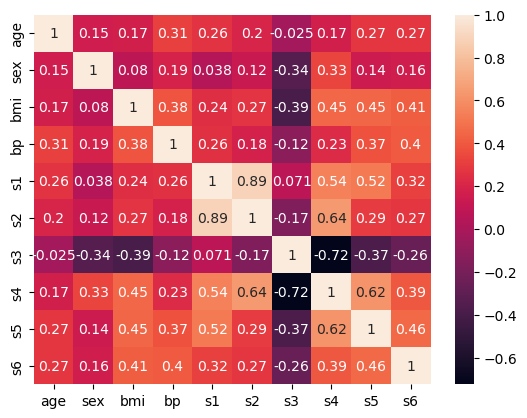

In [9]:
plt.Figure(figsize=(15,10))
sns.heatmap(X_train.corr(),annot=True)

In [10]:
from sklearn.tree import DecisionTreeRegressor

In [11]:
tree_model = DecisionTreeRegressor()

In [12]:
tree_model.fit(X_train,y_train)

DecisionTreeRegressor()

In [13]:
y_pred1 = tree_model.predict(X_test)

In [14]:
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error

In [15]:
print(r2_score(y_test,y_pred1))
print(mean_absolute_error(y_test,y_pred1))
print(mean_squared_error(y_test,y_pred1))

-0.036114124912554724
61.670967741935485
5955.683870967742


In [16]:
#Hyper parme tuning
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor 
tree=DecisionTreeRegressor()
parems = {
    'criterion':["squared_error", "friedman_mse", "absolute_error", "poisson"],
    'splitter':["best", "random"],
    'max_depth':[1,2,3,4,5,6,10,15,20,25],
    'min_samples_split':[1,2,3,4,5,6],
    'max_features':["sqrt", "log2"]
}
grid = GridSearchCV(tree,param_grid=parems,cv=5,scoring='neg_mean_squared_error')

In [17]:
import warnings
warnings.filterwarnings('ignore')
grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(),
             param_grid={'criterion': ['squared_error', 'friedman_mse',
                                       'absolute_error', 'poisson'],
                         'max_depth': [1, 2, 3, 4, 5, 6, 10, 15, 20, 25],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_split': [1, 2, 3, 4, 5, 6],
                         'splitter': ['best', 'random']},
             scoring='neg_mean_squared_error')

In [18]:
y_pred2 = grid.predict(X_test)

In [19]:
print(r2_score(y_test,y_pred2))
print(mean_absolute_error(y_test,y_pred2))
print(mean_squared_error(y_test,y_pred2))

0.2839084809605986
49.89255820974031
4116.163082362854


In [20]:
grid.best_params_

{'criterion': 'friedman_mse',
 'max_depth': 3,
 'max_features': 'sqrt',
 'min_samples_split': 2,
 'splitter': 'best'}

In [21]:
selectmodel=DecisionTreeRegressor(criterion= 'friedman_mse',max_depth= 2,max_features= 'log2',min_samples_split= 6,splitter= 'best')
selectmodel.fit(X_train,y_train)

DecisionTreeRegressor(criterion='friedman_mse', max_depth=2,
                      max_features='log2', min_samples_split=6)

[Text(0.5, 0.8333333333333334, 'x[3] <= 0.024\nfriedman_mse = 6027.411\nsamples = 287\nvalue = 151.655'),
 Text(0.25, 0.5, 'x[8] <= 0.0\nfriedman_mse = 4330.192\nsamples = 199\nvalue = 128.814'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'friedman_mse = 2903.528\nsamples = 125\nvalue = 106.008'),
 Text(0.375, 0.16666666666666666, 'friedman_mse = 4377.44\nsamples = 74\nvalue = 167.338'),
 Text(0.75, 0.5, 'x[7] <= -0.026\nfriedman_mse = 6017.758\nsamples = 88\nvalue = 203.307'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'friedman_mse = 5145.917\nsamples = 19\nvalue = 160.368'),
 Text(0.875, 0.16666666666666666, 'friedman_mse = 5610.345\nsamples = 69\nvalue = 215.13')]

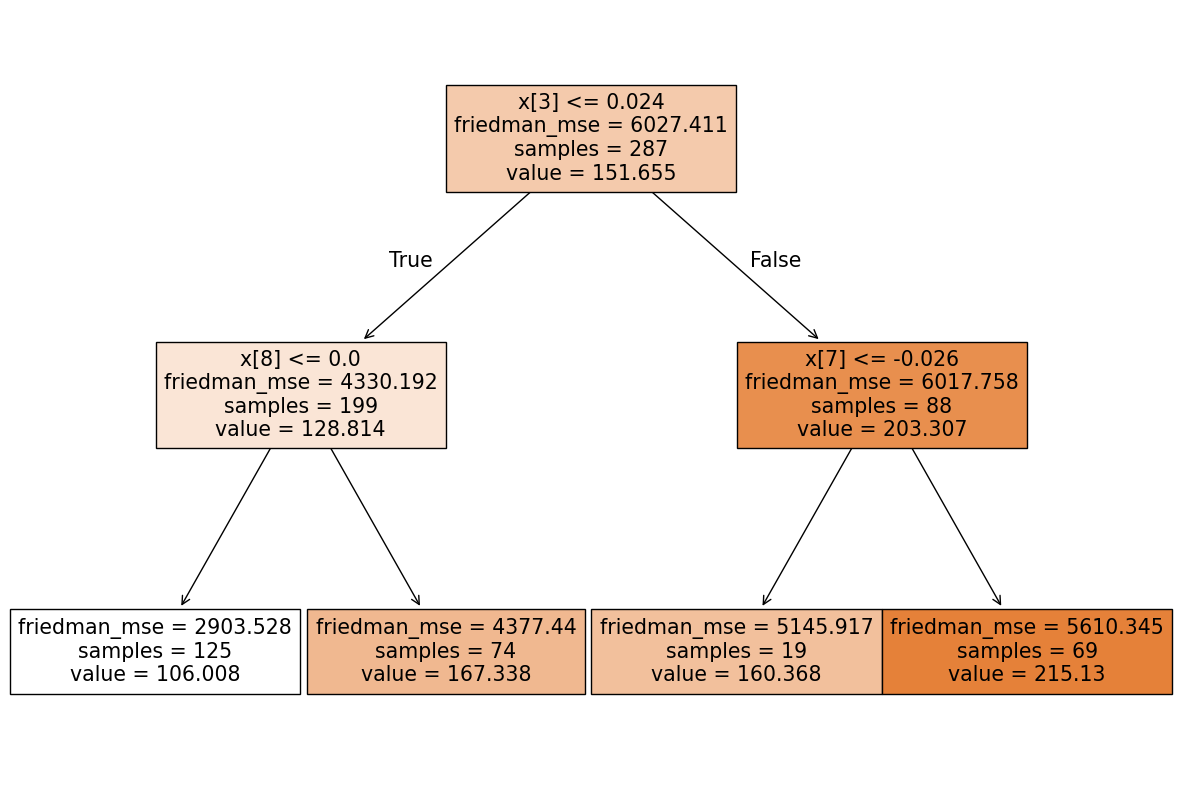

In [22]:
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(selectmodel,filled=True)